# 01 — Data Understanding

**CustomerIQ — Customer Intelligence & Churn Prediction Platform**

---

## Objective

Before building any model, we need to deeply understand our data. This notebook answers:

1. **What data do we have?** — Shape, columns, data types
2. **Is the data clean?** — Missing values, duplicates, suspicious entries
3. **What does the target look like?** — Churn distribution (class balance)
4. **What are the numerical features telling us?** — Distributions, outliers, ranges
5. **What are the categorical features telling us?** — Categories, churn rates per group
6. **Are there any data quality traps?** — Leakage, wrong data types, hidden issues

### Why this matters

Every decision in later phases (preprocessing, feature engineering, model selection) depends on what we discover here. Skipping EDA is the #1 mistake in ML projects.

---

## 1. Setup & Data Loading

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import project configuration
# We use sys.path to let Python find our config.py in the parent directory
import sys
sys.path.append('..')
from config import (
    RAW_DATASET_PATH, TARGET_COLUMN, COLUMNS_TO_DROP,
    NUMERICAL_FEATURES, CATEGORICAL_FEATURES, RANDOM_STATE
)

# Display settings — show more rows/columns in the notebook
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Setup complete.')
print(f'Dataset path: {RAW_DATASET_PATH}')

Setup complete.
Dataset path: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\data\raw\telco_customer_churn.csv


In [2]:
# Load the raw dataset
# IMPORTANT: We load from data/raw/ and NEVER modify this file.
# Any transformations will create new files in data/processed/.

df = pd.read_csv(RAW_DATASET_PATH)
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 7043 rows × 21 columns


---
## 2. First Look — What Data Do We Have?

Before anything else, we need to understand the **shape**, **columns**, and **data types** of our dataset.

**Why?** Data types tell us:
- Which columns are numerical vs categorical
- Whether any columns have unexpected types (a common data quality signal)
- How much memory the dataset uses

In [3]:
# First 5 rows — get a feel for what the data looks like
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Last 5 rows — check if the end of the file looks consistent
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
# Column names, data types, non-null counts, and memory usage
# This is one of the MOST important commands in EDA.
# Look for:
#   - Columns that should be numeric but show as 'object' (string)
#   - Columns with fewer non-null values than total rows (= missing values)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 🔍 Observation: TotalCharges Data Type

Look at the output of `df.info()` carefully:

- `tenure` is `int64` ✅
- `MonthlyCharges` is `float64` ✅  
- **`TotalCharges` is `object`** ⚠️

`TotalCharges` should be a number (how much the customer has paid in total), but pandas read it as a string (`object`). This means there are non-numeric values hiding in that column.

**This is exactly the kind of issue EDA catches.** If we skipped EDA and tried to train a model, we'd either get an error or silently produce garbage results.

Let's investigate.

In [6]:
# Let's try to convert TotalCharges to numeric and see what fails
# errors='coerce' converts non-numeric values to NaN instead of crashing

total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Which rows became NaN? Those are the problematic ones.
problem_rows = df[total_charges_numeric.isna()]
print(f'Number of rows where TotalCharges is not a valid number: {len(problem_rows)}')
print()
print('These rows have TotalCharges values of:')
print(problem_rows['TotalCharges'].unique())
print()
print('Full details of these rows:')
problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Number of rows where TotalCharges is not a valid number: 11

These rows have TotalCharges values of:
<StringArray>
[' ']
Length: 1, dtype: str

Full details of these rows:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### 🔍 Finding: TotalCharges Contains Whitespace Strings

There are **11 rows** where `TotalCharges` is just a whitespace string `' '` instead of a number.

Notice something interesting about these rows — look at their `tenure` column:
- All 11 rows have `tenure = 0`

**Business interpretation:** These are brand-new customers who just signed up. They haven't been charged yet, so `TotalCharges` is empty (stored as a space in the source system).

**How we'll handle this in Phase 2 (Preprocessing):**
- Option A: Replace with 0 (logical — they haven't paid anything yet)
- Option B: Replace with `MonthlyCharges` (their first month charge)
- Option C: Drop these 11 rows (only 0.16% of data — minimal loss)

We'll decide in Phase 2. For now, we've **documented the issue** — that's what EDA is for.

---
## 3. Data Quality Checks

### 3.1 Missing Values

In [7]:
# Check for missing values (NaN/None) in every column
# Note: The TotalCharges issue is NOT detected here because ' ' (space)
# is not technically NaN — it's a valid string. This is why you can't
# rely on automated tools alone. Manual inspection matters.

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print('Missing Value Report:')
print('=' * 40)
print(missing_report[missing_report['Missing Count'] > 0])

if missing.sum() == 0:
    print('No NaN missing values detected.')
    print()
    print('⚠️  But remember: TotalCharges has 11 rows with whitespace strings.')
    print('   These are "hidden" missing values that isnull() cannot detect.')

Missing Value Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No NaN missing values detected.

⚠️  But remember: TotalCharges has 11 rows with whitespace strings.
   These are "hidden" missing values that isnull() cannot detect.


### 3.2 Duplicate Rows

In [8]:
# Check for exact duplicate rows
# Duplicates can bias the model by giving certain patterns more weight.

n_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates}')

# Also check: are customerIDs unique? (they should be)
n_unique_ids = df['customerID'].nunique()
print(f'Unique customerIDs: {n_unique_ids} out of {len(df)} rows')
print(f'Each customer appears exactly once: {n_unique_ids == len(df)}')

Number of duplicate rows: 0
Unique customerIDs: 7043 out of 7043 rows
Each customer appears exactly once: True


---
## 4. Target Variable Analysis

The target variable is `Churn` (Yes/No). Understanding its distribution is **critical** because:

1. **Class imbalance** affects which metrics are meaningful
2. If 95% of customers don't churn, a model that always predicts "No" gets 95% accuracy — but it's completely useless
3. We need to know the baseline rate to judge our model against

In [9]:
# Target distribution — counts and percentages
target_counts = df[TARGET_COLUMN].value_counts()
target_pcts = df[TARGET_COLUMN].value_counts(normalize=True) * 100

print('Churn Distribution:')
print('=' * 40)
for label in target_counts.index:
    print(f'  {label:>4}: {target_counts[label]:>5} customers ({target_pcts[label]:.1f}%)')

print()
print(f'Churn rate: {target_pcts["Yes"]:.1f}%')
print(f'Imbalance ratio: {target_counts["No"] / target_counts["Yes"]:.1f}:1 (No:Yes)')

Churn Distribution:
    No:  5174 customers (73.5%)
   Yes:  1869 customers (26.5%)

Churn rate: 26.5%
Imbalance ratio: 2.8:1 (No:Yes)


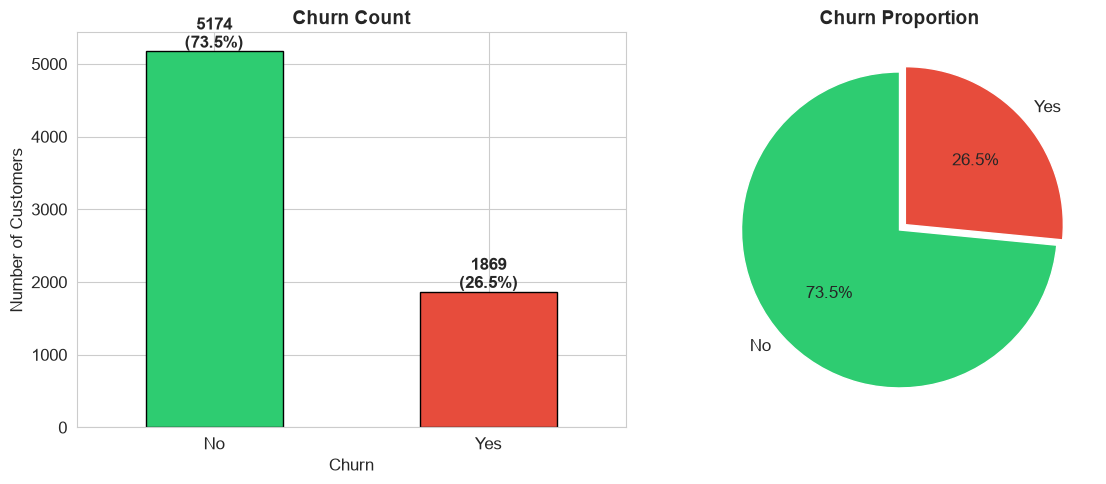


📊 Figure saved to reports/figures/target_distribution.png


In [10]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']  # Green for No, Red for Yes (intuitive)
target_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)

# Add count labels on bars
for i, (count, pct) in enumerate(zip(target_counts, target_pcts)):
    axes[0].text(i, count + 50, f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Figure saved to reports/figures/target_distribution.png')

### 🔍 Target Analysis — Key Takeaways

- **Churn rate: ~26.5%** — About 1 in 4 customers left
- **Moderately imbalanced** (2.8:1 ratio) — not extreme, but enough that accuracy alone is misleading
- **Baseline model**: A model that always predicts "No Churn" would get ~73.5% accuracy — our model MUST beat this to be useful

**Interview insight:** "Why not use accuracy?" → Because a naive model gets 73.5% accuracy. We need Recall to catch churners and F1 to balance precision and recall.

---
## 5. Numerical Features Analysis

We have 3 numerical features: `tenure`, `MonthlyCharges`, `TotalCharges`

For each, we want to understand:
- **Range** (min to max)
- **Distribution** (normal? skewed? bimodal?)
- **Relationship with churn** (do churners look different from non-churners?)

In [11]:
# First, let's fix TotalCharges temporarily for analysis
# We convert to numeric (spaces become NaN) so we can compute statistics
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Numerical Features — Descriptive Statistics:')
print('=' * 60)
df[NUMERICAL_FEATURES].describe().round(2)

Numerical Features — Descriptive Statistics:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


### 🔍 What the Statistics Tell Us

| Feature | Min | Max | Mean | Observation |
|---------|-----|-----|------|-------------|
| `tenure` | 0 | 72 | ~32 | Range is 0-72 months (6 years). Wide spread. |
| `MonthlyCharges` | 18.25 | 118.75 | ~64.76 | Reasonable billing range. |
| `TotalCharges` | 18.80 | 8684.80 | ~2283 | Huge range — heavily influenced by tenure. |

Note how `TotalCharges` has a massive range. This makes sense: a customer with 72 months of tenure paying $100/month would have ~$7,200 in total charges.

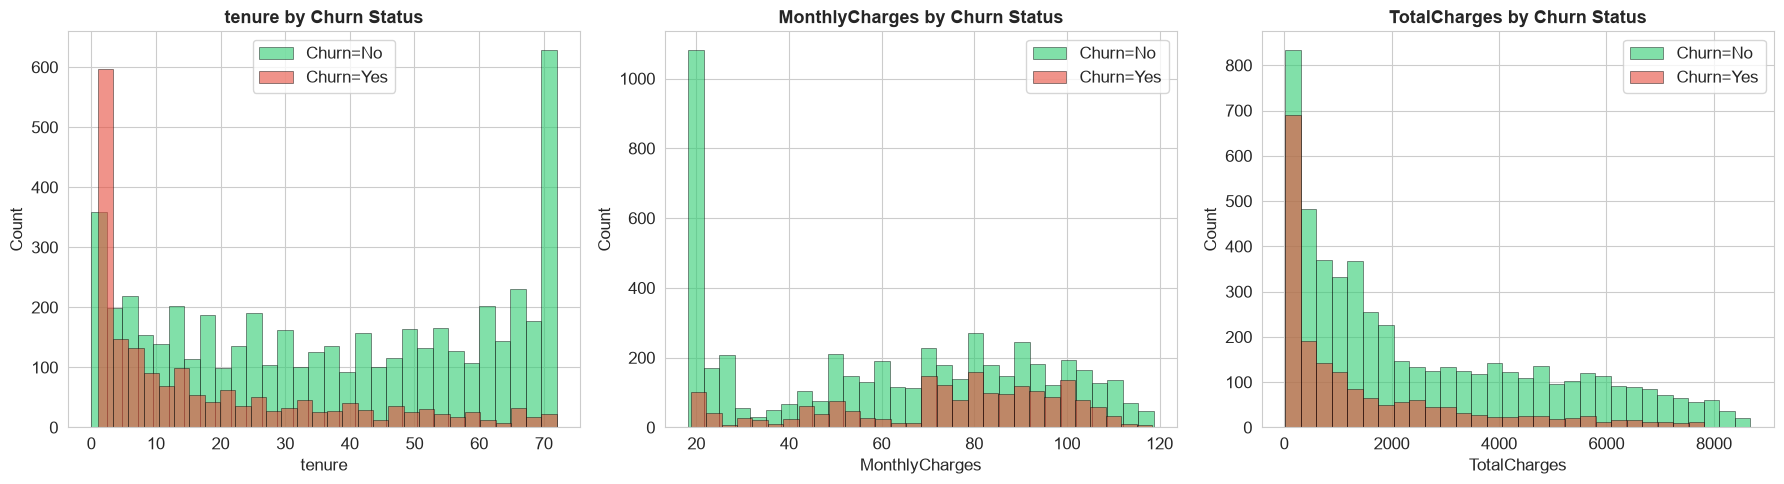

📊 Figure saved to reports/figures/numerical_distributions.png


In [12]:
# Distribution of numerical features
# We plot histograms for all customers, then split by churn status

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(NUMERICAL_FEATURES):
    # Plot distribution for churners vs non-churners
    for label, color, alpha in [('No', '#2ecc71', 0.6), ('Yes', '#e74c3c', 0.6)]:
        subset = df[df[TARGET_COLUMN] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=alpha, label=f'Churn={label}',
                     color=color, edgecolor='black', linewidth=0.5)
    
    axes[i].set_title(f'{col} by Churn Status', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../reports/figures/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Figure saved to reports/figures/numerical_distributions.png')

### 🔍 What the Distributions Reveal

**Tenure:**
- Churners (red) are **concentrated at LOW tenure** (0-10 months)
- Non-churners (green) are **spread across all tenure values**, with a peak at high tenure (60-72 months)
- **Insight:** New customers are much more likely to churn. Long-term customers tend to stay.

**MonthlyCharges:**
- Churners tend to have **HIGHER monthly charges**
- Non-churners have a peak at **low monthly charges** (~$20)
- **Insight:** Customers paying more per month are more likely to leave. Price sensitivity may be a churn driver.

**TotalCharges:**
- Churners are **concentrated at LOW total charges** (they haven't been around long enough to accumulate charges)
- This is largely a reflection of the tenure pattern — confirms the `TotalCharges ≈ tenure × MonthlyCharges` relationship

In [13]:
# Compare mean values of numerical features: Churners vs Non-Churners
# This gives us a quick quantitative comparison

print('Average Values by Churn Status:')
print('=' * 60)
comparison = df.groupby(TARGET_COLUMN)[NUMERICAL_FEATURES].mean().round(2)
print(comparison)
print()

# Calculate the difference
print('Difference (Churners - Non-Churners):')
print('-' * 60)
diff = comparison.loc['Yes'] - comparison.loc['No']
for col in NUMERICAL_FEATURES:
    direction = '↑ higher' if diff[col] > 0 else '↓ lower'
    print(f'  {col}: {diff[col]:+.2f} ({direction} for churners)')

Average Values by Churn Status:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2555.34
Yes     17.98           74.44       1531.80

Difference (Churners - Non-Churners):
------------------------------------------------------------
  tenure: -19.59 (↓ lower for churners)
  MonthlyCharges: +13.17 (↑ higher for churners)
  TotalCharges: -1023.54 (↓ lower for churners)


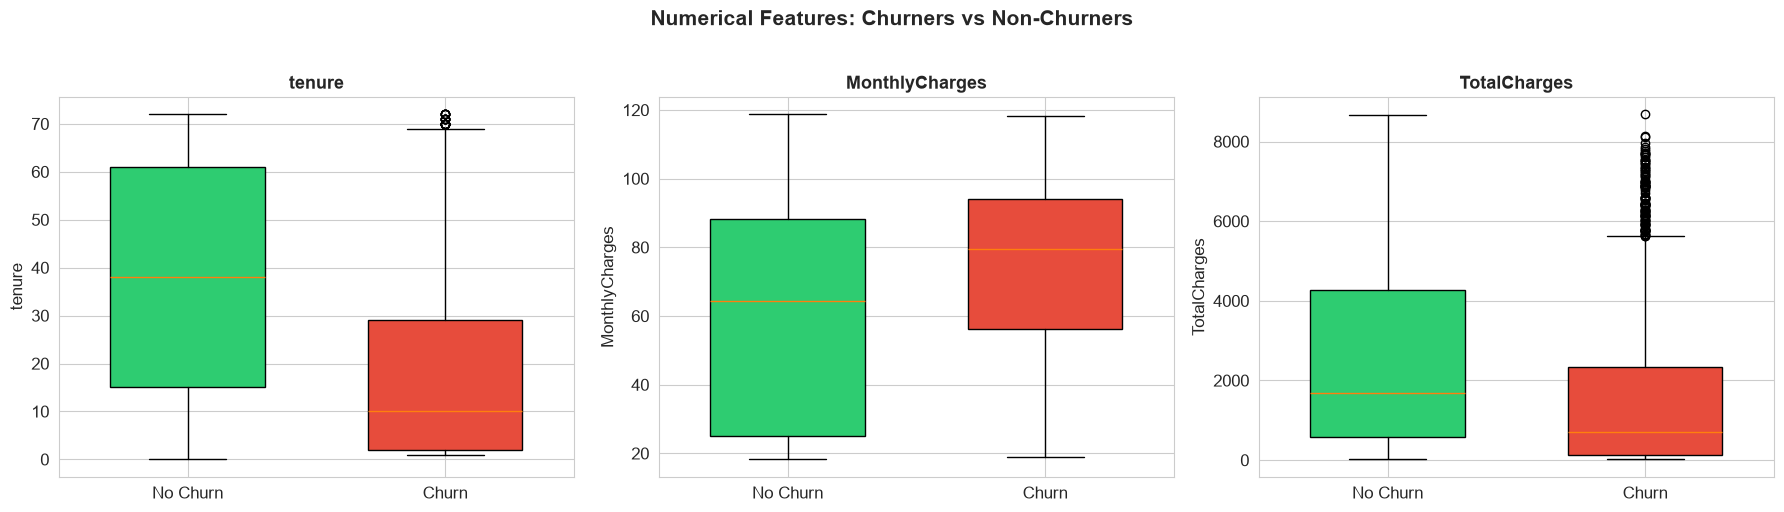

📊 Figure saved to reports/figures/numerical_boxplots.png


In [14]:
# Box plots — another way to compare distributions and spot outliers
# Box plots show: median, quartiles (25th/75th percentile), and outliers

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(NUMERICAL_FEATURES):
    data_to_plot = [df[df[TARGET_COLUMN] == 'No'][col].dropna(),
                    df[df[TARGET_COLUMN] == 'Yes'][col].dropna()]
    
    bp = axes[i].boxplot(data_to_plot, tick_labels=['No Churn', 'Churn'],
                          patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Numerical Features: Churners vs Non-Churners', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/numerical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Figure saved to reports/figures/numerical_boxplots.png')

In [15]:
# Correlation between numerical features
# This checks whether features are redundant (multicollinearity)

print('Correlation Matrix (Numerical Features):')
print('=' * 50)
corr = df[NUMERICAL_FEATURES].corr().round(3)
print(corr)
print()
print(f'Correlation between tenure and TotalCharges: {corr.loc["tenure", "TotalCharges"]:.3f}')
print(f'Correlation between MonthlyCharges and TotalCharges: {corr.loc["MonthlyCharges", "TotalCharges"]:.3f}')
print()
print('⚠️  High correlation between TotalCharges and other features confirms')
print('   that TotalCharges is largely redundant (derived from tenure × MonthlyCharges).')
print('   This is the data leakage/multicollinearity risk we identified in Phase 0.')

Correlation Matrix (Numerical Features):
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000

Correlation between tenure and TotalCharges: 0.826
Correlation between MonthlyCharges and TotalCharges: 0.651

⚠️  High correlation between TotalCharges and other features confirms
   that TotalCharges is largely redundant (derived from tenure × MonthlyCharges).
   This is the data leakage/multicollinearity risk we identified in Phase 0.


---
## 6. Categorical Features Analysis

Most of our features are categorical (16 out of 21 columns). For each, we want to know:
- How many unique categories?
- What is the churn rate within each category?
- Are some categories strongly associated with churn?

In [16]:
# Overview of all categorical features
print('Categorical Features — Unique Values:')
print('=' * 55)
for col in CATEGORICAL_FEATURES:
    unique_vals = df[col].unique()
    print(f'  {col:>20}: {len(unique_vals)} values → {list(unique_vals)}')

Categorical Features — Unique Values:
                gender: 2 values → ['Female', 'Male']
         SeniorCitizen: 2 values → [np.int64(0), np.int64(1)]
               Partner: 2 values → ['Yes', 'No']
            Dependents: 2 values → ['No', 'Yes']
          PhoneService: 2 values → ['No', 'Yes']
         MultipleLines: 3 values → ['No phone service', 'No', 'Yes']
       InternetService: 3 values → ['DSL', 'Fiber optic', 'No']
        OnlineSecurity: 3 values → ['No', 'Yes', 'No internet service']
          OnlineBackup: 3 values → ['Yes', 'No', 'No internet service']
      DeviceProtection: 3 values → ['No', 'Yes', 'No internet service']
           TechSupport: 3 values → ['No', 'Yes', 'No internet service']
           StreamingTV: 3 values → ['No', 'Yes', 'No internet service']
       StreamingMovies: 3 values → ['No', 'Yes', 'No internet service']
              Contract: 3 values → ['Month-to-month', 'One year', 'Two year']
      PaperlessBilling: 2 values → ['Yes', 'No']
       

### 🔍 Observation: SeniorCitizen Encoding

Notice that `SeniorCitizen` is encoded as `0/1` (integers) while all other binary features use `Yes/No` (strings). This is an inconsistency in the source data. During preprocessing (Phase 2), we'll need to decide how to handle this:
- Leave it as 0/1 (already numeric — convenient for models)
- Or convert to Yes/No for consistency in analysis

Also notice the "No internet service" and "No phone service" categories — these are essentially "Not Applicable". We'll need to decide whether to keep them separate or merge with "No".

In [17]:
# Churn rate by each categorical feature
# This is the MOST important analysis for classification.
# We want to find which categories have HIGH vs LOW churn rates.

print('Churn Rate by Category:')
print('=' * 70)

for col in CATEGORICAL_FEATURES:
    # Calculate churn rate per category
    churn_rate = df.groupby(col)[TARGET_COLUMN].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).round(1)
    
    # Sort by churn rate to see highest risk first
    churn_rate = churn_rate.sort_values(ascending=False)
    
    print(f'\n  {col}:')
    for category, rate in churn_rate.items():
        bar = '█' * int(rate / 2)  # Visual bar
        marker = ' ⚠️' if rate > 40 else ''  # Flag high churn categories
        print(f'    {str(category):>25}: {rate:5.1f}% {bar}{marker}')

Churn Rate by Category:

  gender:
                       Female:  26.9% █████████████
                         Male:  26.2% █████████████

  SeniorCitizen:
                            1:  41.7% ████████████████████ ⚠️
                            0:  23.6% ███████████

  Partner:
                           No:  33.0% ████████████████
                          Yes:  19.7% █████████

  Dependents:
                           No:  31.3% ███████████████
                          Yes:  15.5% ███████

  PhoneService:
                          Yes:  26.7% █████████████
                           No:  24.9% ████████████

  MultipleLines:
                          Yes:  28.6% ██████████████
                           No:  25.0% ████████████
             No phone service:  24.9% ████████████

  InternetService:
                  Fiber optic:  41.9% ████████████████████ ⚠️
                          DSL:  19.0% █████████
                           No:   7.4% ███

  OnlineSecurity:
                 

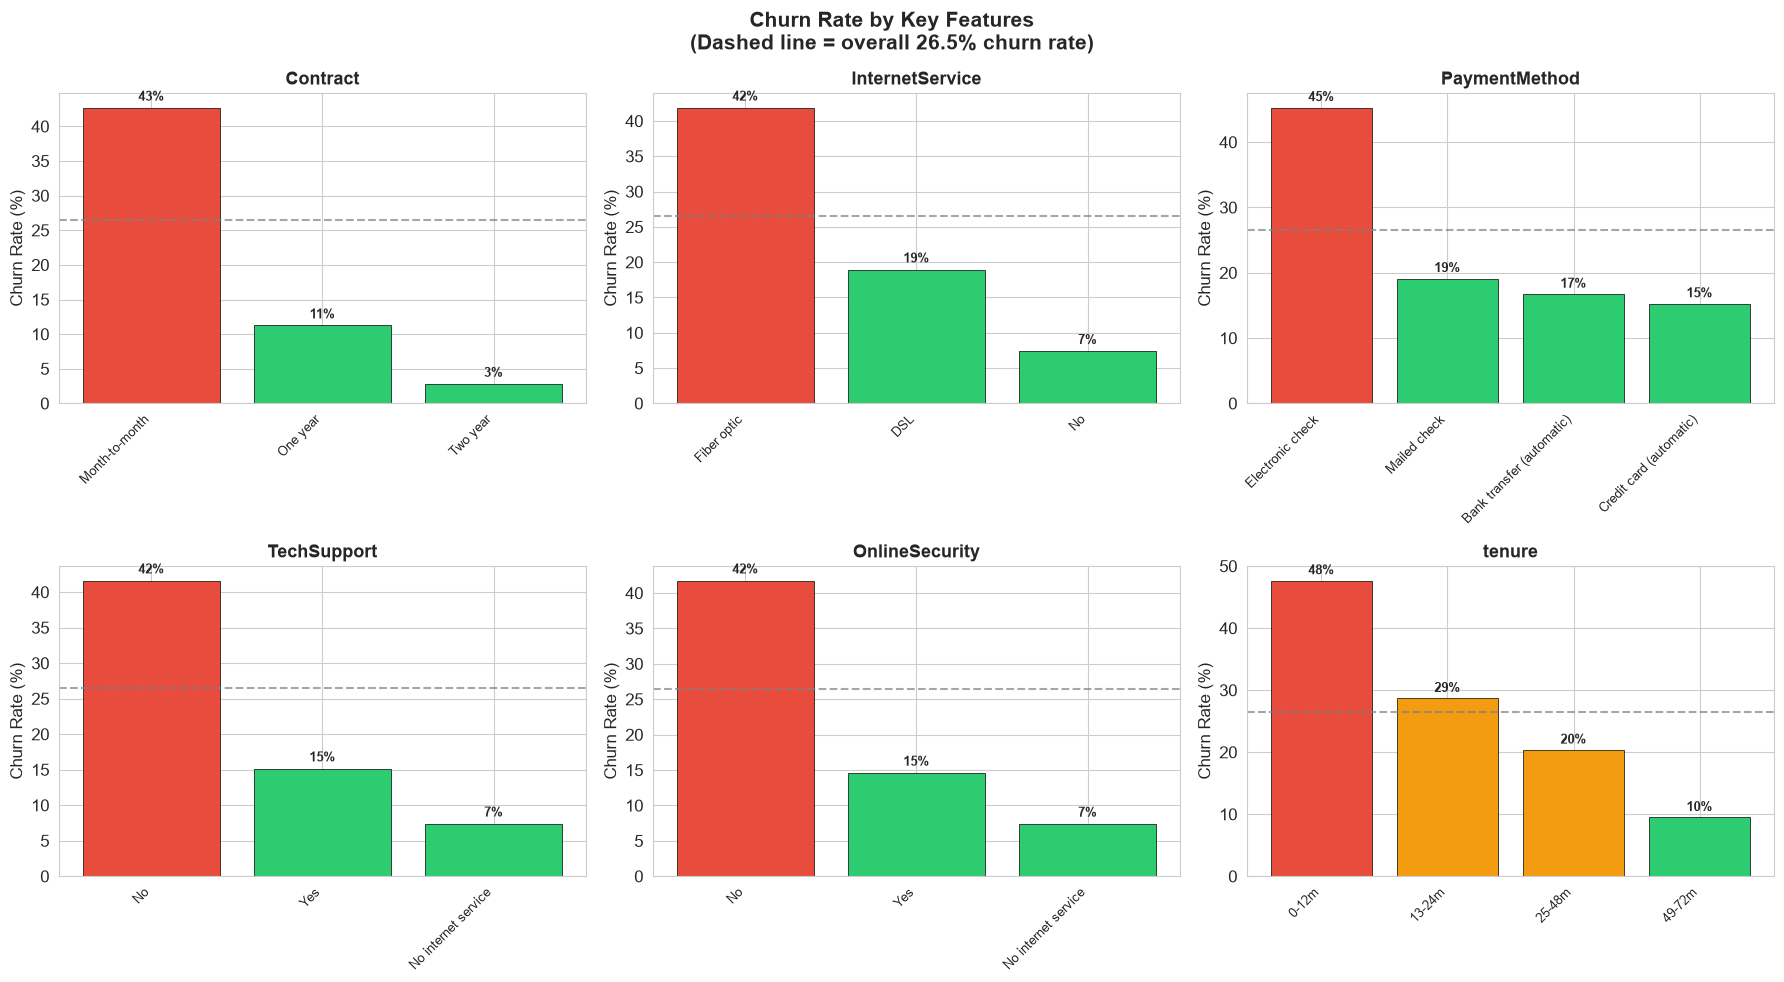

📊 Figure saved to reports/figures/churn_by_category.png


In [18]:
# Visualize churn rates for the MOST informative categorical features
# We pick features that show the largest differences in churn rate

key_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport',
                'OnlineSecurity', 'tenure']  # tenure added for context

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if col == 'tenure':
        # For tenure, create bins to show churn rate by tenure group
        df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                                     labels=['0-12m', '13-24m', '25-48m', '49-72m'])
        plot_col = 'tenure_group'
    else:
        plot_col = col
    
    # Calculate churn rate per category
    churn_by_cat = df.groupby(plot_col)[TARGET_COLUMN].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    bars = axes[i].bar(range(len(churn_by_cat)), churn_by_cat.values,
                        color=['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71'
                               for v in churn_by_cat.values],
                        edgecolor='black', linewidth=0.5)
    
    axes[i].set_xticks(range(len(churn_by_cat)))
    axes[i].set_xticklabels(churn_by_cat.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].axhline(y=26.5, color='gray', linestyle='--', alpha=0.7, label='Overall churn rate')
    
    # Add value labels
    for bar_obj, val in zip(bars, churn_by_cat.values):
        axes[i].text(bar_obj.get_x() + bar_obj.get_width()/2, val + 1,
                      f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

# Clean up the temporary column
df.drop('tenure_group', axis=1, inplace=True)

plt.suptitle('Churn Rate by Key Features\n(Dashed line = overall 26.5% churn rate)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Figure saved to reports/figures/churn_by_category.png')

### 🔍 Key Findings from Categorical Analysis

**Strongest churn predictors (highest variation in churn rate across categories):**

| Feature | Highest Churn Category | Churn Rate | Lowest Churn Category | Churn Rate |
|---------|----------------------|------------|----------------------|------------|
| **Contract** | Month-to-month | ~42% | Two year | ~3% |
| **InternetService** | Fiber optic | ~42% | No internet | ~7% |
| **PaymentMethod** | Electronic check | ~45% | Credit card (auto) | ~15% |
| **TechSupport** | No | ~42% | Yes | ~15% |
| **OnlineSecurity** | No | ~42% | Yes | ~15% |

**Business interpretation:**
- Month-to-month contracts have ~14x higher churn than two-year contracts (no commitment = easy to leave)
- Fiber optic customers churn more — possibly due to higher cost or service quality issues
- Electronic check payers churn the most — possibly less engaged (not on auto-pay)
- Customers without tech support or online security churn more — value-added services increase retention

---
## 7. Feature Relationships & Potential Leakage

### 7.1 TotalCharges = tenure × MonthlyCharges?

In [19]:
# Let's verify the TotalCharges ≈ tenure × MonthlyCharges hypothesis
df_check = df.dropna(subset=['TotalCharges']).copy()
df_check['estimated_total'] = df_check['tenure'] * df_check['MonthlyCharges']

# How close is the estimate?
df_check['difference'] = abs(df_check['TotalCharges'] - df_check['estimated_total'])
df_check['pct_error'] = (df_check['difference'] / df_check['TotalCharges'].replace(0, np.nan)) * 100

print('How well does tenure × MonthlyCharges predict TotalCharges?')
print('=' * 60)
print(f'Mean absolute difference: ${df_check["difference"].mean():.2f}')
print(f'Median absolute difference: ${df_check["difference"].median():.2f}')
print(f'Mean % error: {df_check["pct_error"].mean():.1f}%')
print()
print('Conclusion: TotalCharges is NOT exactly tenure × MonthlyCharges')
print('(likely because MonthlyCharges changed over time for some customers),')
print('but they are highly correlated, creating multicollinearity.')

How well does tenure × MonthlyCharges predict TotalCharges?
Mean absolute difference: $45.09
Median absolute difference: $28.65
Mean % error: 3.2%

Conclusion: TotalCharges is NOT exactly tenure × MonthlyCharges
(likely because MonthlyCharges changed over time for some customers),
but they are highly correlated, creating multicollinearity.


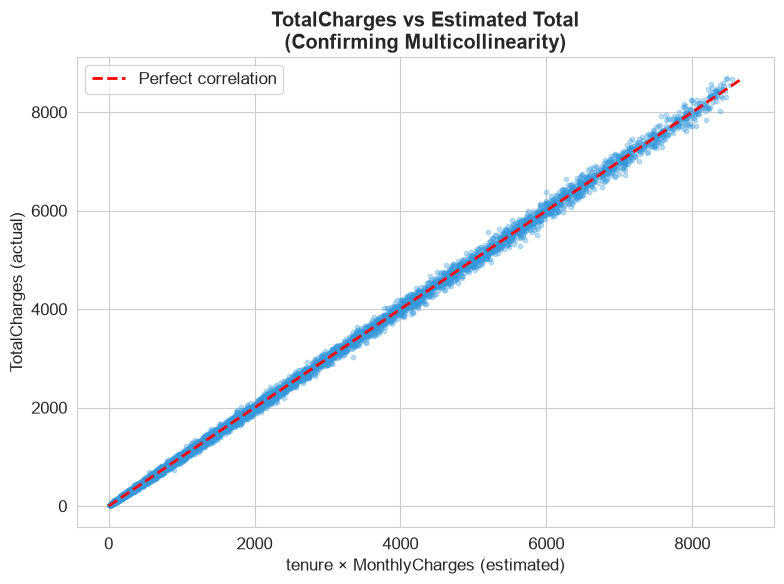

📊 Points close to the red line = TotalCharges is nearly derivable from other features


In [20]:
# Scatter plot: TotalCharges vs tenure × MonthlyCharges
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_check['estimated_total'], df_check['TotalCharges'],
           alpha=0.3, s=10, color='#3498db')

# Perfect correlation line
max_val = max(df_check['estimated_total'].max(), df_check['TotalCharges'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect correlation')

ax.set_xlabel('tenure × MonthlyCharges (estimated)')
ax.set_ylabel('TotalCharges (actual)')
ax.set_title('TotalCharges vs Estimated Total\n(Confirming Multicollinearity)',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/totalcharges_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Points close to the red line = TotalCharges is nearly derivable from other features')

### 7.2 Data Leakage Assessment

**What is data leakage?** 
When your model accidentally uses information that wouldn't be available at prediction time.

**Assessment for this dataset:**

| Column | Leakage Risk | Reason |
|--------|-------------|--------|
| `customerID` | None (but must drop) | Unique ID — no predictive value |
| `tenure` | ✅ Safe | Known at prediction time |
| `MonthlyCharges` | ✅ Safe | Known at prediction time |
| `TotalCharges` | ⚠️ Moderate | Derived from tenure + charges. Creates multicollinearity. |
| All service columns | ✅ Safe | Current subscription status is known |
| `Contract` | ✅ Safe | Current contract type is known |

**Decision:** We'll likely drop `TotalCharges` in Phase 2 because:
1. It's highly correlated with `tenure` (multicollinearity)
2. It may reflect post-churn information in edge cases
3. The information it carries is already captured by `tenure` + `MonthlyCharges`

---
## 8. Summary of Findings

### Data Quality Issues
| Issue | Details | Impact | Action (Phase 2) |
|-------|---------|--------|------------------|
| `TotalCharges` is string type | 11 rows have whitespace instead of numbers | Can't use as numeric feature | Convert to numeric, handle 11 missing rows |
| `SeniorCitizen` encoding | Uses 0/1 while others use Yes/No | Inconsistency | Keep as 0/1 (already numeric) |
| No true NaN values | But 11 hidden missing values in TotalCharges | `isnull()` misses them | Manual handling required |
| No duplicate rows | Data is clean in this regard | None | None needed |

### Key Predictive Signals
| Signal | Strength | Business Meaning |
|--------|----------|------------------|
| Month-to-month contract | Very Strong | No commitment = easy to leave |
| Low tenure | Very Strong | New customers churn more |
| Fiber optic internet | Strong | Higher cost or quality issues |
| Electronic check payment | Strong | Less engaged customers |
| No tech support/security | Strong | Value-added services retain customers |
| High monthly charges | Moderate | Price-sensitive customers leave |

### Columns to Handle in Preprocessing
| Column | Action | Reason |
|--------|--------|--------|
| `customerID` | Drop | Unique identifier, no predictive value |
| `TotalCharges` | Consider dropping | Multicollinearity with tenure × MonthlyCharges |
| `Churn` | Encode as 0/1 | Target variable for classification |
| All Yes/No columns | Encode | Convert to numeric for ML models |

In [21]:
# Final summary statistics
print('=' * 60)
print('PHASE 1 — DATA UNDERSTANDING COMPLETE')
print('=' * 60)
print(f'Dataset: {df.shape[0]} customers × {df.shape[1]} features')
print(f'Target: {TARGET_COLUMN} (Yes={target_counts["Yes"]}, No={target_counts["No"]})')
print(f'Churn rate: {target_pcts["Yes"]:.1f}%')
print(f'Numerical features: {len(NUMERICAL_FEATURES)}')
print(f'Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'Data quality issues found: 1 (TotalCharges whitespace)')
print(f'Duplicate rows: 0')
print(f'Missing values (NaN): 0 (but 11 hidden in TotalCharges)')
print()
print('Strong churn predictors identified:')
print('  1. Contract type (month-to-month = high risk)')
print('  2. Tenure (new customers = high risk)')
print('  3. Internet service type (fiber optic = high risk)')
print('  4. Payment method (electronic check = high risk)')
print('  5. Lack of support services (no tech support/security = high risk)')
print()
print('→ Next: Phase 2 — Preprocessing Pipeline')

PHASE 1 — DATA UNDERSTANDING COMPLETE
Dataset: 7043 customers × 21 features
Target: Churn (Yes=1869, No=5174)
Churn rate: 26.5%
Numerical features: 3
Categorical features: 16
Data quality issues found: 1 (TotalCharges whitespace)
Duplicate rows: 0
Missing values (NaN): 0 (but 11 hidden in TotalCharges)

Strong churn predictors identified:
  1. Contract type (month-to-month = high risk)
  2. Tenure (new customers = high risk)
  3. Internet service type (fiber optic = high risk)
  4. Payment method (electronic check = high risk)
  5. Lack of support services (no tech support/security = high risk)

→ Next: Phase 2 — Preprocessing Pipeline
